Сравнение спецификаций DFM:


,Спецификация,Преобразование,Сезонная корректировка,Число факторов,Порядок фактора,Порядок ошибок,Средний Pseudo R²,Минимальный Pseudo R²,Средняя корреляция,Минимальная корреляция,Доля без автокорреляции,Итоговый score
0,spec_1_center100_e1,center_100,да,1,1,1,0.937,0.892,0.887,0.790,0.333,0.757
1,spec_3_logcenter100_e1,log_center_100,да,1,1,1,0.926,0.886,0.880,0.802,0.333,0.753
2,spec_2_center100_e2,center_100,да,1,1,2,0.939,0.894,0.876,0.761,0.333,0.752


Выбранная модель:


,Показатель,Значение
0,Лучшая спецификация,spec_1_center100_e1
1,Период выборки,2008-01-31 — 2025-12-31
2,Число наблюдений,216
3,Число факторов,1
4,Порядок фактора,1
5,Порядок ошибок,1
6,Преобразования,"industrial_production: center_100, retail_turn..."
7,Сезонная корректировка,да


Диагностика качества лучшей модели:


...

Сводка по качеству лучшей модели:


,Показатель,Значение
0,Средний Pseudo R²,0.937
1,Минимальный Pseudo R²,0.892
2,Средняя корреляция с индексом,0.887
3,Минимальная корреляция с индексом,0.790
4,Доля уравнений без автокорреляции остатков,0.333


Последние 12 значений индекса текущей экономической активности:


,activity_index
2025-01-31,9.6333
2025-02-28,9.4650
2025-03-31,9.9339
2025-04-30,10.0280
2025-05-31,10.0279
2025-06-30,10.3668
2025-07-31,10.4093
2025-08-31,10.6454
2025-09-30,10.9844
2025-10-31,11.2126


Сводка по лучшей модели DFM:
                                                 Statespace Model Results                                                
Dep. Variable:     ['industrial_production', 'retail_turnover', 'paid_services']   No. Observations:                  216
Model:                                         DynamicFactor(factors=1, order=1)   Log Likelihood                 102.893
                                                                  + AR(1) errors   AIC                           -185.786
Date:                                                           Sun, 10 May 2026   BIC                           -152.034
Time:                                                                   08:23:47   HQIC                          -172.150
Sample:                                                               01-31-2008                                         
                                                                    - 12-31-2025                                     

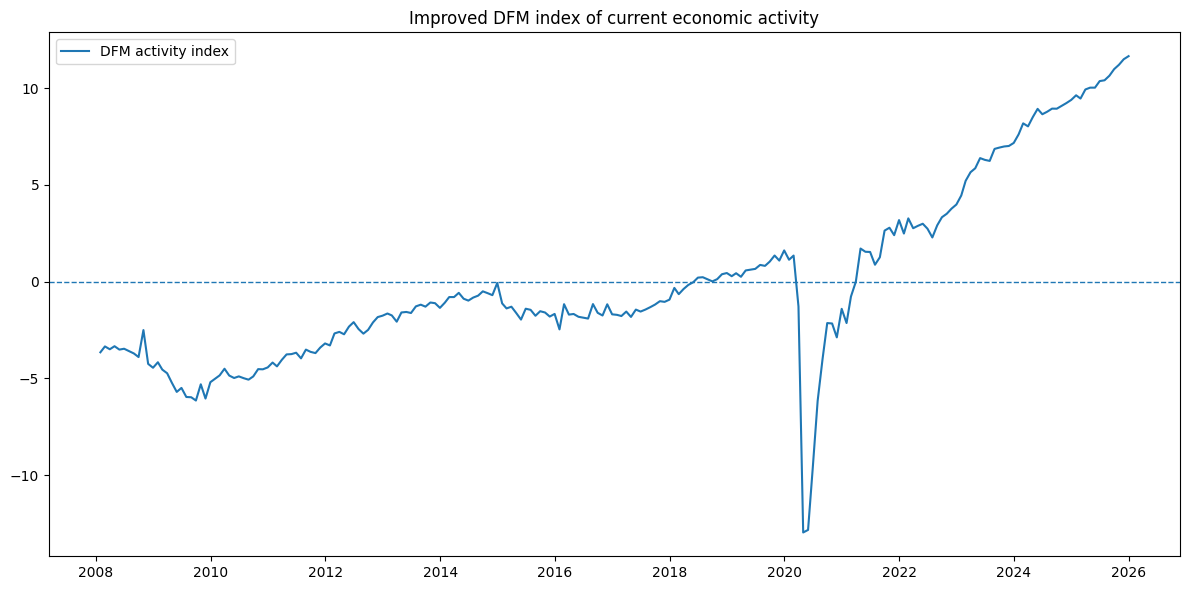

Результаты сохранены в файл: dfm_activity_index_improved.xlsx


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.dynamic_factor import DynamicFactor
from statsmodels.stats.diagnostic import acorr_ljungbox


FILE_PATH = "Данные ВКР.xlsx"
SHEET_NAME = 0
OUTPUT_FILE = "dfm_activity_index_improved.xlsx"

DFM_VARIABLES = [
    "industrial_production",
    "retail_turnover",
    "paid_services",
]

SEASONAL_ADJUST_VARS = DFM_VARIABLES.copy()

SPECIFICATIONS = [
    {
        "name": "spec_1_center100_e1",
        "transforms": {
            "industrial_production": "center_100",
            "retail_turnover": "center_100",
            "paid_services": "center_100",
        },
        "seasonal_adjust": SEASONAL_ADJUST_VARS,
        "n_factors": 1,
        "factor_order": 1,
        "error_order": 1,
    },
    {
        "name": "spec_2_center100_e2",
        "transforms": {
            "industrial_production": "center_100",
            "retail_turnover": "center_100",
            "paid_services": "center_100",
        },
        "seasonal_adjust": SEASONAL_ADJUST_VARS,
        "n_factors": 1,
        "factor_order": 1,
        "error_order": 2,
    },
    {
        "name": "spec_3_logcenter100_e1",
        "transforms": {
            "industrial_production": "log_center_100",
            "retail_turnover": "log_center_100",
            "paid_services": "log_center_100",
        },
        "seasonal_adjust": SEASONAL_ADJUST_VARS,
        "n_factors": 1,
        "factor_order": 1,
        "error_order": 1,
    },
]


def to_float_ru(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    s = s.replace("\xa0", "").replace(" ", "").replace(",", ".")
    if s == "":
        return np.nan
    return float(s)


def read_data(file_path: str, sheet_name=0) -> pd.DataFrame:
    if file_path.lower().endswith((".xlsx", ".xls")):
        df = pd.read_excel(file_path, sheet_name=sheet_name)
    elif file_path.lower().endswith(".csv"):
        df = pd.read_csv(file_path)
    else:
        raise ValueError("Используй .xlsx, .xls или .csv")
    return df


def clean_col_name(s):
    return str(s).replace("\xa0", " ").replace("\n", " ").strip()


def norm_col_name(s):
    return clean_col_name(s).upper()


def build_column_mapping(columns):
    norm_to_orig = {norm_col_name(c): c for c in columns}

    def find_col(exact=None, contains=None):
        if exact is not None:
            exact_norm = norm_col_name(exact)
            if exact_norm in norm_to_orig:
                return norm_to_orig[exact_norm]
        if contains is not None:
            contains_norm = norm_col_name(contains)
            for c in columns:
                if contains_norm in norm_col_name(c):
                    return c
        return None

    rename_map = {}
    first_col = columns[0]
    rename_map[first_col] = "date"

    col = find_col(exact="ИПП")
    if col is not None:
        rename_map[col] = "iip_old"

    col = find_col(exact="ИПП совмещенные", contains="ИПП СОВМ")
    if col is not None:
        rename_map[col] = "industrial_production"

    col = find_col(exact="Оборот розничной торговли в % к предыдущему периоду", contains="ОБОРОТ РОЗНИЧ")
    if col is not None:
        rename_map[col] = "retail_old"

    col = find_col(exact="ОБОРОТ new", contains="ОБОРОТ NEW")
    if col is not None:
        rename_map[col] = "retail_turnover"

    col = find_col(exact="Объем платных услуг населению", contains="ПЛАТНЫХ УСЛУГ")
    if col is not None:
        rename_map[col] = "paid_services_old"

    col = find_col(exact="Объем платных услуг населению new", contains="ПЛАТНЫХ УСЛУГ НАСЕЛЕНИЮ NEW")
    if col is not None:
        rename_map[col] = "paid_services"

    col = find_col(exact="ИПЦ")
    if col is not None:
        rename_map[col] = "cpi_raw"

    col = find_col(exact="ИПЦ new", contains="ИПЦ NEW")
    if col is not None:
        rename_map[col] = "cpi_new"

    col = find_col(exact="доллар", contains="ДОЛЛАР")
    if col is not None:
        rename_map[col] = "usd_rub"

    col = find_col(exact="MOEX", contains="MOEX")
    if col is not None:
        rename_map[col] = "imoex"

    col = find_col(exact="ключевая ставка", contains="КЛЮЧЕВАЯ СТАВКА")
    if col is not None:
        rename_map[col] = "key_rate"

    col = find_col(exact="BRENT USD", contains="BRENT")
    if col is not None:
        rename_map[col] = "brent"

    col = find_col(exact="VIX", contains="VIX")
    if col is not None:
        rename_map[col] = "vix"

    col = find_col(exact="GPR", contains="GPR")
    if col is not None:
        rename_map[col] = "gpr"

    return rename_map


def make_monthly_index(df: pd.DataFrame, date_col: str) -> pd.DataFrame:
    df = df.copy()
    df[date_col] = (
        df[date_col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors="coerce")
    df = df.dropna(subset=[date_col])
    df[date_col] = df[date_col].dt.to_period("M").dt.to_timestamp("M")
    df = df.sort_values(date_col).drop_duplicates(subset=[date_col])
    df = df.set_index(date_col)
    full_range = pd.date_range(df.index.min(), df.index.max(), freq="M")
    df = df.reindex(full_range)
    return df


def seasonal_adjust_stl(series: pd.Series, period: int = 12) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce").copy()
    if s.notna().sum() < 24:
        return s
    s_interp = s.interpolate(limit_direction="both")
    res = STL(s_interp, period=period, robust=True).fit()
    sa = s_interp - res.seasonal
    sa[s.isna()] = np.nan
    return sa


def transform_series(series: pd.Series, method: str) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce").copy()

    if method == "log_diff":
        if (s <= 0).any():
            raise ValueError(f"{series.name}: есть неположительные значения, log_diff нельзя применить")
        return 100 * np.log(s).diff()
    elif method == "diff":
        return s.diff()
    elif method == "identity":
        return s
    elif method == "center_100":
        return s - 100
    elif method == "log_center_100":
        if (s <= 0).any():
            raise ValueError(f"{series.name}: есть неположительные значения, log_center_100 нельзя применить")
        return 100 * np.log(s / 100)
    else:
        raise ValueError(f"Неизвестный метод: {method}")


def standardize_df(df: pd.DataFrame) -> pd.DataFrame:
    return (df - df.mean()) / df.std(ddof=0)


def orient_factor_sign(factor: pd.Series, reference: pd.Series) -> pd.Series:
    corr = factor.corr(reference)
    if pd.notna(corr) and corr < 0:
        return -factor
    return factor


def prepare_model_data(data: pd.DataFrame, transforms: dict, seasonal_adjust_list: list) -> tuple:
    sa_data = data.copy()
    for col in seasonal_adjust_list:
        sa_data[col] = seasonal_adjust_stl(sa_data[col])

    transformed = pd.DataFrame(index=sa_data.index)
    for col in data.columns:
        transformed[col] = transform_series(sa_data[col], transforms[col])

    model_data = transformed.dropna().copy()
    model_data_std = standardize_df(model_data)
    return model_data, model_data_std


def fit_dfm_and_diagnostics(model_data, model_data_std, n_factors, factor_order, error_order):
    dfm = DynamicFactor(
        model_data_std,
        k_factors=n_factors,
        factor_order=factor_order,
        error_order=error_order,
    )
    res = dfm.fit(maxiter=1000, disp=False)

    factor = pd.Series(
        res.factors.filtered[0],
        index=model_data_std.index,
        name="activity_index"
    )
    factor = orient_factor_sign(factor, model_data_std["industrial_production"])

    fitted_raw = res.fittedvalues
    if isinstance(fitted_raw, pd.DataFrame):
        fitted_std = fitted_raw.copy()
    else:
        fitted_std = pd.DataFrame(
            fitted_raw,
            index=model_data_std.index,
            columns=model_data_std.columns
        )

    resid_std = model_data_std - fitted_std

    quality_rows = []
    for col in model_data_std.columns:
        corr_with_index = factor.corr(model_data_std[col])
        pseudo_r2 = 1 - (resid_std[col].var(ddof=0) / model_data_std[col].var(ddof=0))
        lb_pvalue = acorr_ljungbox(
            resid_std[col].dropna(),
            lags=[12],
            return_df=True
        )["lb_pvalue"].iloc[0]

        quality_rows.append({
            "Переменная": col,
            "Корреляция с индексом": corr_with_index,
            "Pseudo R²": pseudo_r2,
            "Ljung-Box p-value (12)": lb_pvalue
        })

    quality_table = pd.DataFrame(quality_rows)

    summary_quality = pd.DataFrame({
        "Показатель": [
            "Средний Pseudo R²",
            "Минимальный Pseudo R²",
            "Средняя корреляция с индексом",
            "Минимальная корреляция с индексом",
            "Доля уравнений без автокорреляции остатков"
        ],
        "Значение": [
            quality_table["Pseudo R²"].mean(),
            quality_table["Pseudo R²"].min(),
            quality_table["Корреляция с индексом"].mean(),
            quality_table["Корреляция с индексом"].min(),
            (quality_table["Ljung-Box p-value (12)"] > 0.05).mean()
        ]
    })

    score = (
        0.55 * summary_quality.loc[0, "Значение"] +
        0.25 * summary_quality.loc[4, "Значение"] +
        0.20 * summary_quality.loc[3, "Значение"]
    )

    return res, factor, quality_table, summary_quality, score


raw = read_data(FILE_PATH, sheet_name=SHEET_NAME)
raw.columns = [clean_col_name(c) for c in raw.columns]

rename_map = build_column_mapping(raw.columns.tolist())
raw = raw.rename(columns=rename_map)

if "date" not in raw.columns:
    raise ValueError("Не найден столбец с датой")

raw = make_monthly_index(raw, "date")

all_numeric_cols = [
    "iip_old", "industrial_production",
    "retail_old", "retail_turnover",
    "paid_services_old", "paid_services",
    "cpi_raw", "cpi_new",
    "usd_rub", "imoex", "key_rate", "brent", "vix", "gpr",
]

for col in all_numeric_cols:
    if col in raw.columns:
        raw[col] = raw[col].map(to_float_ru)

missing_cols = [col for col in DFM_VARIABLES if col not in raw.columns]
if missing_cols:
    raise ValueError(f"В файле отсутствуют столбцы для DFM: {missing_cols}")

data = raw[DFM_VARIABLES].copy()


comparison_rows = []
all_results = {}

for spec in SPECIFICATIONS:
    model_data, model_data_std = prepare_model_data(
        data=data,
        transforms=spec["transforms"],
        seasonal_adjust_list=spec["seasonal_adjust"],
    )
    res, factor, quality_table, summary_quality, score = fit_dfm_and_diagnostics(
        model_data=model_data,
        model_data_std=model_data_std,
        n_factors=spec["n_factors"],
        factor_order=spec["factor_order"],
        error_order=spec["error_order"],
    )

    all_results[spec["name"]] = {
        "spec": spec,
        "model_data": model_data,
        "model_data_std": model_data_std,
        "res": res,
        "factor": factor,
        "quality_table": quality_table,
        "summary_quality": summary_quality,
        "score": score,
    }

    comparison_rows.append({
        "Спецификация": spec["name"],
        "Преобразование": ", ".join(set(spec["transforms"].values())),
        "Сезонная корректировка": "да" if len(spec["seasonal_adjust"]) > 0 else "нет",
        "Число факторов": spec["n_factors"],
        "Порядок фактора": spec["factor_order"],
        "Порядок ошибок": spec["error_order"],
        "Средний Pseudo R²": summary_quality.loc[0, "Значение"],
        "Минимальный Pseudo R²": summary_quality.loc[1, "Значение"],
        "Средняя корреляция": summary_quality.loc[2, "Значение"],
        "Минимальная корреляция": summary_quality.loc[3, "Значение"],
        "Доля без автокорреляции": summary_quality.loc[4, "Значение"],
        "Итоговый score": score
    })

comparison_table = pd.DataFrame(comparison_rows).sort_values(
    by="Итоговый score", ascending=False
).reset_index(drop=True)

best_spec_name = comparison_table.loc[0, "Спецификация"]
best_result = all_results[best_spec_name]

best_spec = best_result["spec"]
model_data = best_result["model_data"]
model_data_std = best_result["model_data_std"]
res = best_result["res"]
factor = best_result["factor"]
quality_table = best_result["quality_table"]
summary_quality = best_result["summary_quality"]

results_df = model_data.copy()
results_df["activity_index"] = factor

results_full = raw.join(results_df[["activity_index"]], how="left")

info_table = pd.DataFrame({
    "Показатель": [
        "Лучшая спецификация",
        "Период выборки",
        "Число наблюдений",
        "Число факторов",
        "Порядок фактора",
        "Порядок ошибок",
        "Преобразования",
        "Сезонная корректировка"
    ],
    "Значение": [
        best_spec["name"],
        f"{model_data_std.index.min().date()} — {model_data_std.index.max().date()}",
        len(model_data_std),
        best_spec["n_factors"],
        best_spec["factor_order"],
        best_spec["error_order"],
        ", ".join([f"{k}: {v}" for k, v in best_spec["transforms"].items()]),
        "да" if len(best_spec["seasonal_adjust"]) > 0 else "нет"
    ]
})

display(comparison_table.round(3))
display(info_table)
display(quality_table.round(3))
display(summary_quality.round(3))
display(results_df[["activity_index"]].tail(12).round(4))
print(res.summary())

print("\nУравнения наблюдений (x_it = λ_i * f_t + ε_it):")
params = res.params
for i, col in enumerate(model_data_std.columns):
    loading = params[f"loading.f1.{col}"]
    print(f"  {col:30s}  x_t = {loading:.4f} * f_t + ε_t")

phi = params["L1.f1.f1"]
print(f"\nУравнение состояния (f_t = φ_1 * f_t-1 + η_t):")
print(f"  f_t = {phi:.4f} * f_{{t-1}} + η_t")

print("\nДисперсии идиосинкратических ошибок (σ²_ε):")
for col in model_data_std.columns:
    try:
        var = params[f"sigma2.{col}"]
        print(f"  {col:30s}  σ² = {var:.4f}")
    except KeyError:
        pass


with pd.ExcelWriter(OUTPUT_FILE) as writer:
    comparison_table.to_excel(writer, sheet_name="model_comparison", index=False)
    quality_table.to_excel(writer, sheet_name="quality_best_model", index=False)
    summary_quality.to_excel(writer, sheet_name="summary_best_model", index=False)
    results_df.to_excel(writer, sheet_name="dfm_index")
    results_full.to_excel(writer, sheet_name="full_data_with_index")


plt.figure(figsize=(12, 6))
plt.plot(results_df.index, results_df["activity_index"], label="DFM activity index")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Improved DFM index of current economic activity")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Результаты сохранены: {OUTPUT_FILE}")


Итоговая спецификация BVAR:


,Показатель,Значение
0,Период оценки,2008-04-30 — 2025-12-31
1,Число наблюдений,213
2,Источник инфляции,cpi_new
3,Выбранные лаги,2
4,Выбранный lambda,0.5
5,Макс. модуль корня,0.987
6,VAR устойчив,да


Краткая диагностика модели:


,Переменная,In-sample R²,Ljung-Box p-value
0,activity_index,0.961,0.025
1,inflation_mom,0.998,0.000
2,usd_rub_change,0.189,0.325
3,policy_rate,0.944,0.261



Posterior mean коэффициентов BVAR:
    activity_index  inflation_mom  usd_rub_change  policy_rate
0           0.0157         0.0182          0.0048       0.0071
1           0.8569         0.0639          0.2298       0.1203
2           0.1017         0.8663         -0.1153      -0.0831
3          -0.0042         0.0013          0.0384       0.0576
4           0.0290        -0.0003         -0.3061       0.8976
5           0.0044         0.0071         -0.0052       0.0057
6           0.0077         0.0527          0.0091      -0.0045
7          -0.0101         0.0015          0.0370       0.0334
8          -0.0048        -0.0025          0.0290       0.0201
9           0.0615         0.0125         -0.2885       0.0123
10         -0.0185         0.0048          0.0927      -0.0034
11          0.0121         0.0191         -0.0199       0.0551


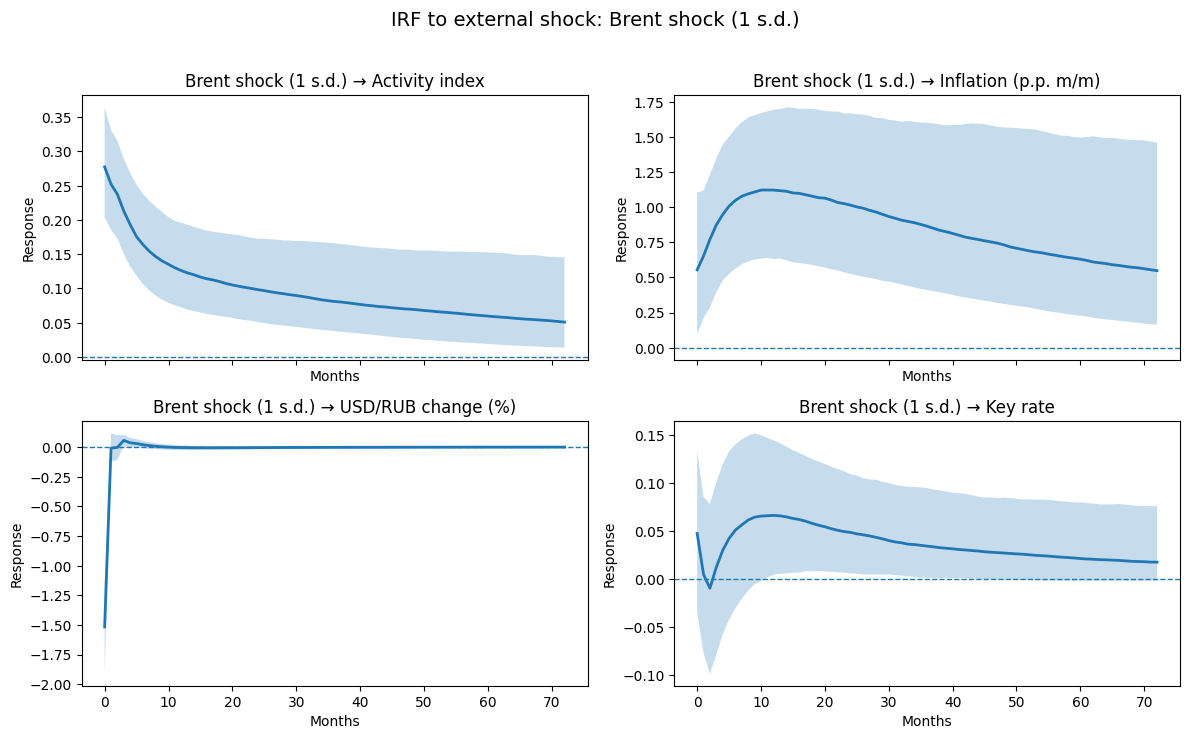

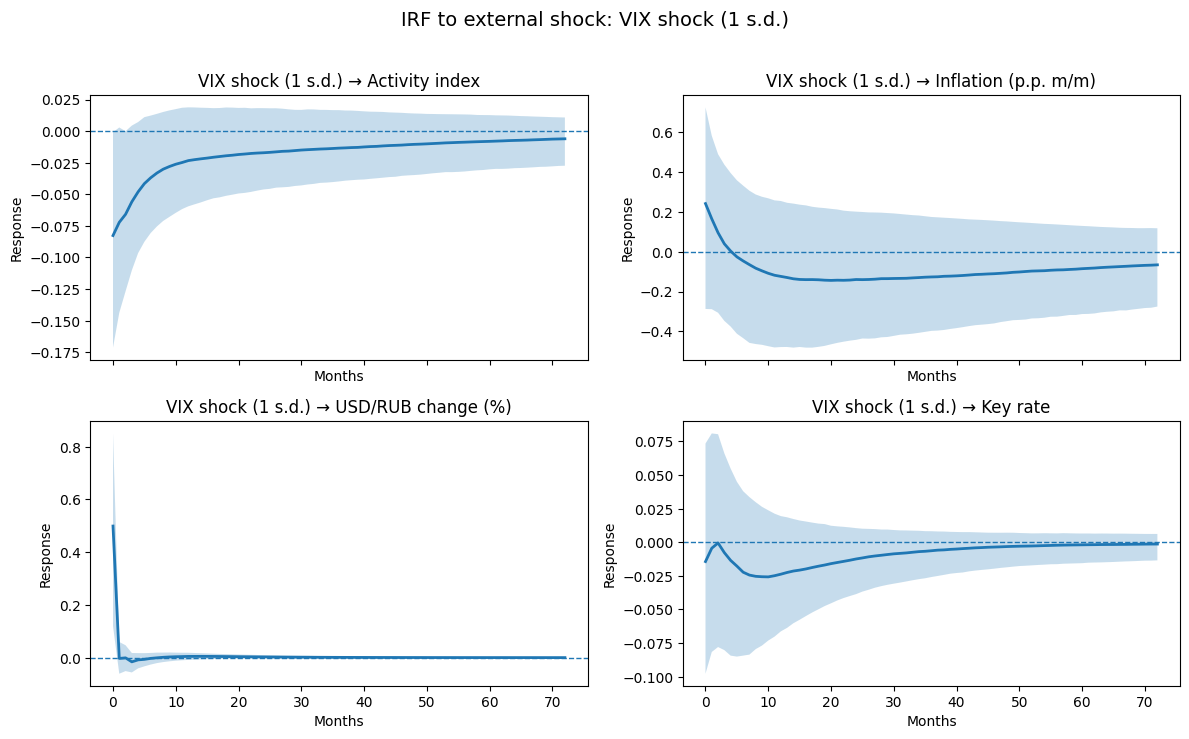

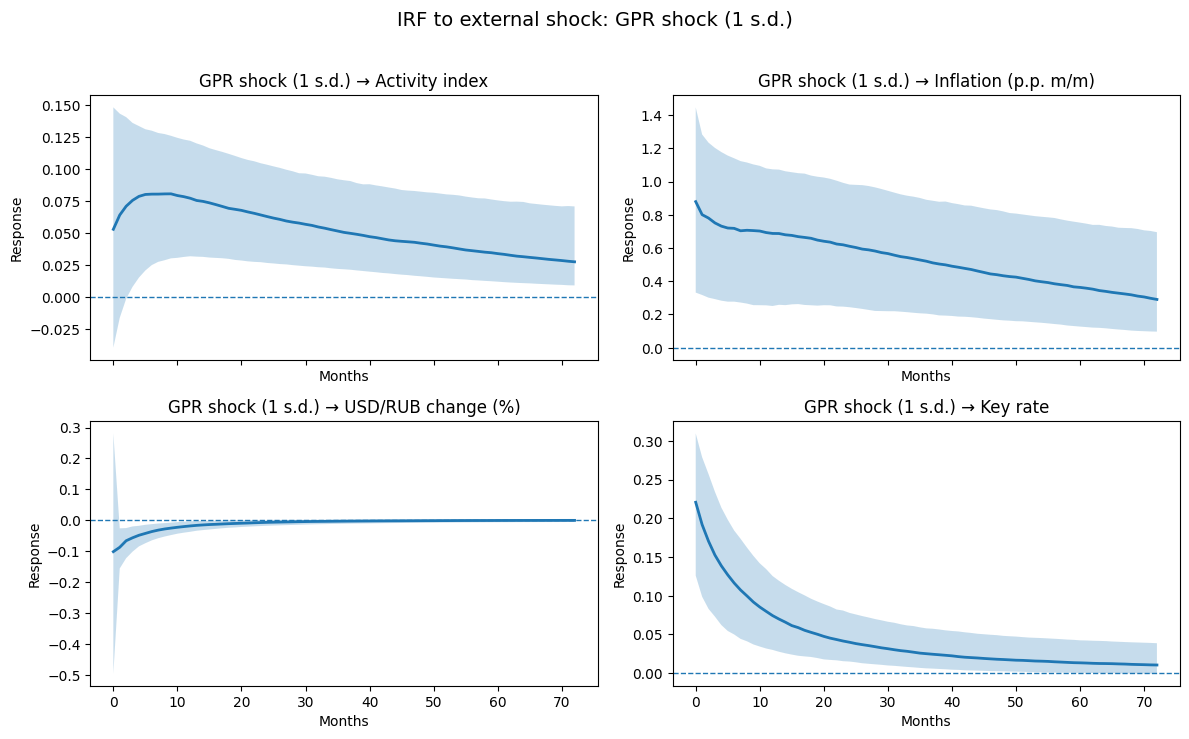

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import invwishart
from statsmodels.stats.diagnostic import acorr_ljungbox


LAGS_GRID = [2, 3, 4, 6, 8, 10]
LAMBDA_GRID = [0.20, 0.35, 0.50]

EVAL_SIZE = 72
N_DRAWS = 1200
BURN = 600
HORIZON = 72

SHOW_EXOG_IRF = True
SHOW_ENDOG_IRF = False

SEED = 42


def zscore_series(s):
    s = pd.to_numeric(s, errors="coerce")
    std = s.std(ddof=0)
    if pd.isna(std) or std == 0:
        return s * np.nan
    return (s - s.mean()) / std


def standardize_df(df):
    means = df.mean()
    stds = df.std(ddof=0).replace(0, np.nan)
    out = (df - means) / stds
    return out, means, stds


def build_lagged_design(endog_df, lags=6, exog_df=None):
    X = pd.DataFrame(index=endog_df.index)
    X["const"] = 1.0

    for L in range(1, lags + 1):
        lag_block = endog_df.shift(L).copy()
        lag_block.columns = [f"{c}_L{L}" for c in lag_block.columns]
        X = X.join(lag_block)

    if exog_df is not None and exog_df.shape[1] > 0:
        X = X.join(exog_df)

    all_df = pd.concat([endog_df, X], axis=1).dropna()
    Y = all_df[endog_df.columns].copy()
    Z = all_df[X.columns].copy()
    return Y, Z


def make_prior(n_endog, lags, n_exog, overall_lambda=0.35, exog_lambda=0.50, const_scale=10.0):
    k = 1 + n_endog * lags + n_exog
    B0 = np.zeros((k, n_endog))
    v = np.zeros(k)
    v[0] = const_scale ** 2

    idx = 1
    for L in range(1, lags + 1):
        for _ in range(n_endog):
            v[idx] = (overall_lambda / (L ** 2)) ** 2
            idx += 1

    for _ in range(n_exog):
        v[idx] = exog_lambda ** 2
        idx += 1

    V0 = np.diag(v)
    S0 = np.eye(n_endog)
    nu0 = n_endog + 2
    return B0, V0, S0, nu0


def posterior_mniw(Y, Z, B0, V0, S0, nu0):
    Ymat = Y.values
    Zmat = Z.values

    V0_inv = np.linalg.inv(V0)
    Vn_inv = Zmat.T @ Zmat + V0_inv
    Vn = np.linalg.inv(Vn_inv)
    Bn = Vn @ (Zmat.T @ Ymat + V0_inv @ B0)
    nu_n = nu0 + Ymat.shape[0]
    Sn = S0 + Ymat.T @ Ymat + B0.T @ V0_inv @ B0 - Bn.T @ Vn_inv @ Bn
    Sn = (Sn + Sn.T) / 2
    return Bn, Vn, Sn, nu_n


def draw_posterior(Bn, Vn, Sn, nu_n, n_draws=1000, burn=500, seed=42):
    rng = np.random.default_rng(seed)
    k, n = Bn.shape
    chol_Vn = np.linalg.cholesky(Vn)

    B_draws = []
    Sigma_draws = []

    for s in range(n_draws + burn):
        Sigma = invwishart.rvs(df=nu_n, scale=Sn, random_state=rng)
        chol_Sigma = np.linalg.cholesky(Sigma)
        E = rng.normal(size=(k, n))
        B = Bn + chol_Vn @ E @ chol_Sigma.T

        if s >= burn:
            B_draws.append(B)
            Sigma_draws.append(Sigma)

    return np.array(B_draws), np.array(Sigma_draws)


def unpack_B(B, n_endog, lags, n_exog):
    c = B[0, :].copy()
    A = []
    idx = 1
    for _ in range(lags):
        block = B[idx:idx + n_endog, :]
        A.append(block.T)
        idx += n_endog

    if n_exog > 0:
        G = B[idx:idx + n_exog, :].T
    else:
        G = np.zeros((n_endog, 0))

    return c, A, G


def companion_max_root(B, n_endog, lags):
    _, A, _ = unpack_B(B, n_endog, lags, n_exog=0)
    top = np.hstack(A)

    if lags == 1:
        companion = top
    else:
        bottom = np.hstack([
            np.eye(n_endog * (lags - 1)),
            np.zeros((n_endog * (lags - 1), n_endog))
        ])
        companion = np.vstack([top, bottom])

    eigvals = np.linalg.eigvals(companion)
    return np.max(np.abs(eigvals))


def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum((y_true - y_true.mean()) ** 2)
    if denom <= 1e-12:
        return np.nan
    return 1 - np.sum((y_true - y_pred) ** 2) / denom


def irf_endog(B, Sigma, n_endog, lags, horizon=12):
    _, A, _ = unpack_B(B, n_endog, lags, n_exog=0)
    P = np.linalg.cholesky(Sigma)
    out = np.zeros((n_endog, horizon + 1, n_endog))

    for shock_idx in range(n_endog):
        history = [np.zeros(n_endog) for _ in range(lags)]
        y0 = P[:, shock_idx]
        out[shock_idx, 0, :] = y0
        history[0] = y0

        for h in range(1, horizon + 1):
            yh = np.zeros(n_endog)
            for L in range(1, lags + 1):
                yh += A[L - 1] @ history[L - 1]
            out[shock_idx, h, :] = yh
            history = [yh] + history[:-1]

    return out


def irf_exog(B, n_endog, lags, n_exog, horizon=12, shock_sizes=None):
    _, A, G = unpack_B(B, n_endog, lags, n_exog)
    if shock_sizes is None:
        shock_sizes = np.ones(n_exog)

    out = np.zeros((n_exog, horizon + 1, n_endog))

    for shock_idx in range(n_exog):
        history = [np.zeros(n_endog) for _ in range(lags)]
        y0 = G[:, shock_idx] * shock_sizes[shock_idx]
        out[shock_idx, 0, :] = y0
        history[0] = y0

        for h in range(1, horizon + 1):
            yh = np.zeros(n_endog)
            for L in range(1, lags + 1):
                yh += A[L - 1] @ history[L - 1]
            out[shock_idx, h, :] = yh
            history = [yh] + history[:-1]

    return out


def summarize_irf(irf_draws, q_low=0.16, q_med=0.50, q_high=0.84):
    low = np.quantile(irf_draws, q_low, axis=0)
    med = np.quantile(irf_draws, q_med, axis=0)
    high = np.quantile(irf_draws, q_high, axis=0)
    return low, med, high


def plot_irf_grid(irf_low, irf_med, irf_high, var_names, shock_names, title_prefix="IRF"):
    n_shocks = len(shock_names)
    n_vars = len(var_names)
    horizons = np.arange(irf_med.shape[1])

    for s in range(n_shocks):
        ncols = 2
        nrows = int(np.ceil(n_vars / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.6 * nrows), sharex=True)
        axes = np.array(axes).reshape(-1)

        for i in range(n_vars):
            ax = axes[i]
            ax.plot(horizons, irf_med[s, :, i], linewidth=2)
            ax.fill_between(horizons, irf_low[s, :, i], irf_high[s, :, i], alpha=0.25)
            ax.axhline(0, linestyle="--", linewidth=1)
            ax.set_title(f"{shock_names[s]} → {var_names[i]}")
            ax.set_xlabel("Months")
            ax.set_ylabel("Response")

        for j in range(n_vars, len(axes)):
            axes[j].axis("off")

        fig.suptitle(f"{title_prefix}: {shock_names[s]}", fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()


def evaluate_spec(Y, Z, n_endog, lags, n_exog, overall_lambda, eval_size=12):
    if len(Y) <= eval_size + 12:
        raise ValueError("Слишком короткая выборка для оценки и holdout-проверки.")

    Y_train = Y.iloc[:-eval_size].copy()
    Z_train = Z.iloc[:-eval_size].copy()
    Y_test = Y.iloc[-eval_size:].copy()
    Z_test = Z.iloc[-eval_size:].copy()

    B0, V0, S0, nu0 = make_prior(n_endog=n_endog, lags=lags, n_exog=n_exog, overall_lambda=overall_lambda)
    Bn, Vn, Sn, nu_n = posterior_mniw(Y_train, Z_train, B0, V0, S0, nu0)
    B_mean = Bn.copy()

    Y_hat_train = pd.DataFrame(Z_train.values @ B_mean, index=Y_train.index, columns=Y_train.columns)
    Y_hat_test = pd.DataFrame(Z_test.values @ B_mean, index=Y_test.index, columns=Y_test.columns)

    train_r2 = {}
    test_r2 = {}
    lb_pvals = {}
    resid_train = Y_train - Y_hat_train

    for col in Y.columns:
        train_r2[col] = safe_r2(Y_train[col], Y_hat_train[col])
        test_r2[col] = safe_r2(Y_test[col], Y_hat_test[col])
        lb_lag = min(12, max(3, len(resid_train) // 10))
        lb_pvals[col] = acorr_ljungbox(
            resid_train[col].dropna(),
            lags=[lb_lag],
            return_df=True
        )["lb_pvalue"].iloc[0]

    max_root = companion_max_root(B_mean, n_endog=n_endog, lags=lags)
    stable_flag = float(max_root < 1.0)
    white_share = np.mean([p > 0.05 for p in lb_pvals.values()])
    avg_train_r2 = np.nanmean(list(train_r2.values()))
    avg_test_r2 = np.nanmean(list(test_r2.values()))
    min_test_r2 = np.nanmin(list(test_r2.values()))

    score = (
        0.45 * avg_test_r2 +
        0.20 * min_test_r2 +
        0.20 * avg_train_r2 +
        0.10 * white_share +
        0.05 * stable_flag
    )

    return {
        "lags": lags,
        "lambda": overall_lambda,
        "avg_train_r2": avg_train_r2,
        "avg_test_r2": avg_test_r2,
        "min_test_r2": min_test_r2,
        "white_share": white_share,
        "max_root": max_root,
        "stable_flag": stable_flag,
        "score": score
    }


required_cols = ["usd_rub", "key_rate", "brent", "vix", "gpr"]
missing = [c for c in required_cols if c not in raw.columns]
if missing:
    raise ValueError(f"В raw отсутствуют столбцы: {missing}")

if "activity_index" not in results_df.columns:
    raise ValueError("В results_df нет activity_index")

bvar_df = raw.copy()
bvar_df = bvar_df.join(results_df[["activity_index"]], how="left")

inflation_source = "cpi_new" if "cpi_new" in bvar_df.columns else "cpi_raw"
if inflation_source not in bvar_df.columns:
    raise ValueError("Нет ни cpi_new, ни cpi_raw")

bvar_df["inflation_mom"] = bvar_df[inflation_source] - 100
bvar_df["usd_rub_change"] = 100 * np.log(bvar_df["usd_rub"]).diff()
bvar_df["policy_rate"] = bvar_df["key_rate"]
bvar_df["brent_change"] = 100 * np.log(bvar_df["brent"]).diff()
bvar_df["vix_std"] = zscore_series(bvar_df["vix"])
bvar_df["gpr_std"] = zscore_series(bvar_df["gpr"])
bvar_df["brent_change_std"] = zscore_series(bvar_df["brent_change"])

endog_cols = [
    "activity_index",
    "inflation_mom",
    "usd_rub_change",
    "policy_rate",
]

exog_cols = [
    "brent_change_std",
    "vix_std",
    "gpr_std",
]

work_df = bvar_df[endog_cols + exog_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

endog_raw = work_df[endog_cols].copy()
exog_raw = work_df[exog_cols].copy()

endog_z, endog_means, endog_stds = standardize_df(endog_raw)
exog_z, exog_means, exog_stds = standardize_df(exog_raw)

if endog_z.isna().any().any() or exog_z.isna().any().any():
    raise ValueError("После стандартизации появились NaN.")


comparison_rows = []
for lags in LAGS_GRID:
    Y_tmp, Z_tmp = build_lagged_design(endog_z, lags=lags, exog_df=exog_z)
    for lam in LAMBDA_GRID:
        res_eval = evaluate_spec(
            Y=Y_tmp, Z=Z_tmp,
            n_endog=len(endog_cols),
            lags=lags,
            n_exog=len(exog_cols),
            overall_lambda=lam,
            eval_size=EVAL_SIZE
        )
        comparison_rows.append(res_eval)

comparison_table = pd.DataFrame(comparison_rows).sort_values(
    by="score", ascending=False
).reset_index(drop=True)

best_lags = int(comparison_table.loc[0, "lags"])
best_lambda = float(comparison_table.loc[0, "lambda"])

Y, Z = build_lagged_design(endog_z, lags=best_lags, exog_df=exog_z)


B0, V0, S0, nu0 = make_prior(
    n_endog=len(endog_cols),
    lags=best_lags,
    n_exog=len(exog_cols),
    overall_lambda=best_lambda
)

Bn, Vn, Sn, nu_n = posterior_mniw(Y, Z, B0, V0, S0, nu0)
B_draws, Sigma_draws = draw_posterior(
    Bn, Vn, Sn, nu_n,
    n_draws=N_DRAWS,
    burn=BURN,
    seed=SEED
)

B_post_mean = B_draws.mean(axis=0)
Sigma_post_mean = Sigma_draws.mean(axis=0)

Y_hat = pd.DataFrame(Z.values @ B_post_mean, index=Y.index, columns=Y.columns)
resid = Y - Y_hat

diag_rows = []
for col in Y.columns:
    lb_lag = min(12, max(3, len(resid) // 10))
    lb_pval = acorr_ljungbox(
        resid[col].dropna(),
        lags=[lb_lag],
        return_df=True
    )["lb_pvalue"].iloc[0]

    diag_rows.append({
        "Переменная": col,
        "In-sample R²": safe_r2(Y[col], Y_hat[col]),
        "Ljung-Box p-value": lb_pval
    })

diag_table = pd.DataFrame(diag_rows)

summary_table = pd.DataFrame({
    "Показатель": [
        "Период оценки",
        "Число наблюдений",
        "Источник инфляции",
        "Выбранные лаги",
        "Выбранный lambda",
        "Макс. модуль корня",
        "VAR устойчив"
    ],
    "Значение": [
        f"{Y.index.min().strftime('%Y-%m-%d')} — {Y.index.max().strftime('%Y-%m-%d')}",
        len(Y),
        inflation_source,
        best_lags,
        round(best_lambda, 3),
        round(companion_max_root(B_post_mean, len(endog_cols), best_lags), 3),
        "да" if companion_max_root(B_post_mean, len(endog_cols), best_lags) < 1.0 else "нет"
    ]
})


response_scale = endog_stds[endog_cols].values.reshape(1, 1, -1)

pretty_var_names = [
    "Activity index",
    "Inflation (p.p. m/m)",
    "USD/RUB change (%)",
    "Key rate"
]

pretty_exog_shocks = [
    "Brent shock (1 s.d.)",
    "VIX shock (1 s.d.)",
    "GPR shock (1 s.d.)"
]

pretty_endog_shocks = [
    "Activity shock",
    "Inflation shock",
    "FX shock",
    "Rate shock"
]

if SHOW_EXOG_IRF:
    irf_exog_draws = []
    for d in range(B_draws.shape[0]):
        irf_exog_draws.append(
            irf_exog(
                B=B_draws[d],
                n_endog=len(endog_cols),
                lags=best_lags,
                n_exog=len(exog_cols),
                horizon=HORIZON,
                shock_sizes=np.ones(len(exog_cols))
            )
        )
    irf_exog_draws = np.array(irf_exog_draws)
    exog_low, exog_med, exog_high = summarize_irf(irf_exog_draws)
    exog_low = exog_low * response_scale
    exog_med = exog_med * response_scale
    exog_high = exog_high * response_scale

if SHOW_ENDOG_IRF:
    irf_endog_draws = []
    for d in range(B_draws.shape[0]):
        irf_endog_draws.append(
            irf_endog(
                B=B_draws[d],
                Sigma=Sigma_draws[d],
                n_endog=len(endog_cols),
                lags=best_lags,
                horizon=HORIZON
            )
        )
    irf_endog_draws = np.array(irf_endog_draws)
    endog_low, endog_med, endog_high = summarize_irf(irf_endog_draws)
    endog_low = endog_low * response_scale
    endog_med = endog_med * response_scale
    endog_high = endog_high * response_scale


display(summary_table)
display(diag_table.round(3))
print("\nPosterior mean коэффициентов BVAR:")
print(pd.DataFrame(B_post_mean, columns=endog_cols).round(4).to_string())

if SHOW_EXOG_IRF:
    plot_irf_grid(
        irf_low=exog_low,
        irf_med=exog_med,
        irf_high=exog_high,
        var_names=pretty_var_names,
        shock_names=pretty_exog_shocks,
        title_prefix="IRF to external shock"
    )

if SHOW_ENDOG_IRF:
    plot_irf_grid(
        irf_low=endog_low,
        irf_med=endog_med,
        irf_high=endog_high,
        var_names=pretty_var_names,
        shock_names=pretty_endog_shocks,
        title_prefix="Orthogonalized IRF"
    )


FEVD по внешним шокам (медианные доли, %):


,variable,horizon,shock,fevd_low_pct,fevd_median_pct,fevd_high_pct
0,Activity index,1,Brent shock (1 s.d.),52.67,80.23,94.89
1,Activity index,1,VIX shock (1 s.d.),0.83,7.53,29.06
2,Activity index,1,GPR shock (1 s.d.),0.74,6.12,21.98
3,Activity index,3,Brent shock (1 s.d.),53.83,80.16,94.61
4,Activity index,3,VIX shock (1 s.d.),0.77,6.97,26.88
...,...,...,...,...,...,...
103,Key rate,60,VIX shock (1 s.d.),1.76,7.18,24.19
104,Key rate,60,GPR shock (1 s.d.),17.07,51.94,80.53
105,Key rate,72,Brent shock (1 s.d.),8.81,33.10,69.14
106,Key rate,72,VIX shock (1 s.d.),1.77,7.08,23.90


FEVD на горизонте 12 месяцев (медиана, %):


shock,Brent shock (1 s.d.),GPR shock (1 s.d.),VIX shock (1 s.d.)
variable,,,
Activity index,75.58,13.12,5.85
Inflation (p.p. m/m),56.33,32.58,4.97
Key rate,18.31,63.40,7.94
USD/RUB change (%),82.80,4.42,9.30


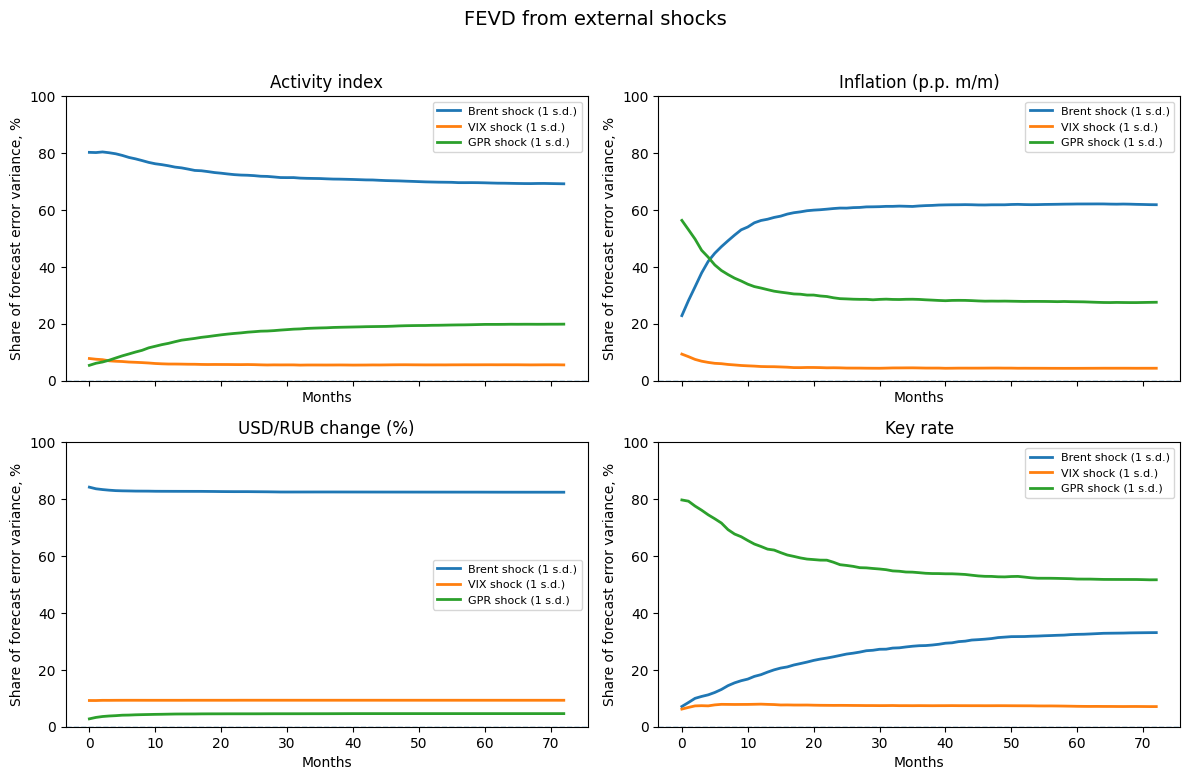

FEVD сохранен в файл: bvar_fevd_external.xlsx


In [5]:
FEVD_HORIZONS_TO_SHOW = [1, 3, 6, 12, 24, 36, 48, 60, 72]
FEVD_OUTPUT_FILE = "bvar_fevd_external.xlsx"


def fevd_from_irf_draws(irf_draws):
    sq = irf_draws ** 2
    cum_sq = np.cumsum(sq, axis=2)
    total = cum_sq.sum(axis=1, keepdims=True)
    fevd = np.divide(cum_sq, total, out=np.zeros_like(cum_sq), where=total > 1e-12)
    return fevd


def summarize_fevd(fevd_draws, q_low=0.16, q_med=0.50, q_high=0.84):
    low = np.quantile(fevd_draws, q_low, axis=0)
    med = np.quantile(fevd_draws, q_med, axis=0)
    high = np.quantile(fevd_draws, q_high, axis=0)
    return low, med, high


def build_fevd_table(fevd_low, fevd_med, fevd_high, var_names, shock_names, horizons_to_show=None):
    max_h = fevd_med.shape[1] - 1
    if horizons_to_show is None:
        horizons_to_show = list(range(max_h + 1))
    horizons_to_show = [h for h in horizons_to_show if 0 <= h <= max_h]

    rows = []
    for i_var, var in enumerate(var_names):
        for h in horizons_to_show:
            for i_shock, shock in enumerate(shock_names):
                rows.append({
                    "variable": var,
                    "horizon": h,
                    "shock": shock,
                    "fevd_low_pct": 100 * fevd_low[i_shock, h, i_var],
                    "fevd_median_pct": 100 * fevd_med[i_shock, h, i_var],
                    "fevd_high_pct": 100 * fevd_high[i_shock, h, i_var],
                })
    return pd.DataFrame(rows)


def plot_fevd_grid(fevd_med, var_names, shock_names, title_prefix="FEVD from external shocks"):
    horizons = np.arange(fevd_med.shape[1])
    n_vars = len(var_names)
    ncols = 2
    nrows = int(np.ceil(n_vars / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.8 * nrows), sharex=True)
    axes = np.array(axes).reshape(-1)

    for i in range(n_vars):
        ax = axes[i]
        for s, shock_name in enumerate(shock_names):
            ax.plot(horizons, 100 * fevd_med[s, :, i], linewidth=2, label=shock_name)
        ax.set_title(var_names[i])
        ax.set_xlabel("Months")
        ax.set_ylabel("Share of forecast error variance, %")
        ax.set_ylim(0, 100)
        ax.axhline(0, linestyle="--", linewidth=1)
        ax.legend(fontsize=8)

    for j in range(n_vars, len(axes)):
        axes[j].axis("off")

    fig.suptitle(title_prefix, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


irf_exog_draws_for_fevd = []
for d in range(B_draws.shape[0]):
    irf_exog_draws_for_fevd.append(
        irf_exog(
            B=B_draws[d],
            n_endog=len(endog_cols),
            lags=best_lags,
            n_exog=len(exog_cols),
            horizon=HORIZON,
            shock_sizes=np.ones(len(exog_cols))
        )
    )
irf_exog_draws_for_fevd = np.array(irf_exog_draws_for_fevd)

fevd_draws = fevd_from_irf_draws(irf_exog_draws_for_fevd)
fevd_low, fevd_med, fevd_high = summarize_fevd(fevd_draws)

fevd_table = build_fevd_table(
    fevd_low=fevd_low,
    fevd_med=fevd_med,
    fevd_high=fevd_high,
    var_names=pretty_var_names,
    shock_names=pretty_exog_shocks,
    horizons_to_show=FEVD_HORIZONS_TO_SHOW
)

h12 = 12 if HORIZON >= 12 else HORIZON
fevd_h12 = (
    fevd_table[fevd_table["horizon"] == h12]
    .pivot(index="variable", columns="shock", values="fevd_median_pct")
    .round(2)
)

display(fevd_table.round(2))
display(fevd_h12)

plot_fevd_grid(
    fevd_med=fevd_med,
    var_names=pretty_var_names,
    shock_names=pretty_exog_shocks,
    title_prefix="FEVD from external shocks"
)

with pd.ExcelWriter(FEVD_OUTPUT_FILE, engine="openpyxl") as writer:
    fevd_table.to_excel(writer, sheet_name="FEVD_all_horizons", index=False)
    fevd_h12.to_excel(writer, sheet_name=f"FEVD_h{h12}")

print(f"FEVD сохранен: {FEVD_OUTPUT_FILE}")
